# 05 – Final evaluation on the test set

This is the **only** place the test set is used: trials registered in **2018** (10,970 labelled trials), which the models have never seen.

**Decisions fixed before this notebook (see notebook 04 and the README):**
- **Primary model:** logistic regression on all 41 features. **Also reported:** LightGBM with the settings tuned in notebook 04 (read from `reports/04_final_model.json`).
- Both are **retrained on train + validation** (registrations up to 2017) with those settings unchanged. More data, and closer in time to 2018.
- Scored **once** on test. The results are reported as they come out. Nothing gets tuned after this point.

## 1. Load the data and the saved settings

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

from src.evaluate import evaluate
from src.features import ALL_FEATURES, load_features
from src.models import make_lgbm, make_logreg

PROJECT = Path.cwd().parent
settings = json.loads((PROJECT / "reports" / "04_final_model.json").read_text())
print(json.dumps(settings, indent=2))

df = load_features()
development = df[df["split"].isin(["train", "valid"])]
test = df[df["split"] == "test"]

X_dev, y_dev = development[ALL_FEATURES], development["label"]
X_test, y_test = test[ALL_FEATURES], test["label"]

print(f"development (train + valid): {len(X_dev):,} trials, {y_dev.mean():.1%} stopped early")
print(f"test (2018 registrations):   {len(X_test):,} trials, {y_test.mean():.1%} stopped early")
assert (len(X_dev), len(X_test)) == (11776 + 9157, 10970)

{
  "primary_model": "logistic_regression",
  "logistic_regression_params": {
    "max_iter": 2000
  },
  "lightgbm_params": {
    "num_leaves": 15,
    "min_child_samples": 20,
    "n_estimators": 200
  },
  "n_features": 41,
  "valid_scores": {
    "logistic_regression": {
      "pr_auc": 0.383,
      "roc_auc": 0.696,
      "brier": 0.148
    },
    "lightgbm": {
      "pr_auc": 0.391,
      "roc_auc": 0.708,
      "brier": 0.146
    }
  }
}
development (train + valid): 20,933 trials, 20.6% stopped early
test (2018 registrations):   10,970 trials, 19.8% stopped early


## 2. Retrain both models on train + validation

In [2]:
logreg = make_logreg(**settings["logistic_regression_params"])
logreg.fit(X_dev, y_dev)

lgbm = make_lgbm(**settings["lightgbm_params"])
lgbm.fit(X_dev, y_dev)

test_prob = {
    "no model (predict the stop rate)": np.full(len(y_test), y_dev.mean()),
    "logistic regression (primary)": logreg.predict_proba(X_test)[:, 1],
    "LightGBM": lgbm.predict_proba(X_test)[:, 1],
}

## 3. Test-set results

In [3]:
test_results = pd.DataFrame(
    [evaluate(y_test, prob, name) for name, prob in test_prob.items()]
).set_index("model").round(3)
display(test_results[["n_trials", "positive_rate", "pr_auc", "roc_auc", "brier"]])

,n_trials,positive_rate,pr_auc,roc_auc,brier
model,,,,,
no model (predict the stop rate),10970,0.198,0.198,0.500,0.159
logistic regression (primary),10970,0.198,0.346,0.676,0.156
LightGBM,10970,0.198,0.361,0.698,0.148


## 4. How certain are these numbers? Bootstrap 95% intervals

The test set is one sample of trials. **Bootstrapping** redraws it 1,000 times (with replacement), re-scores each redraw, and takes the middle 95% of the scores. A range that is narrow and well above the no-skill level means the result isn't luck.

The last row answers the notebook-04 question directly: **is LightGBM really better than logistic regression?** If the interval for the difference contains 0, the answer is no.

In [4]:
rng = np.random.default_rng(42)
y = y_test.to_numpy()
p_lr = test_prob["logistic regression (primary)"]
p_gb = test_prob["LightGBM"]

draws = []
for _ in range(1000):
    idx = rng.integers(0, len(y), len(y))
    if y[idx].min() == y[idx].max():   # a redraw with only one class can't be scored
        continue
    draws.append({
        "lr_pr_auc": average_precision_score(y[idx], p_lr[idx]),
        "gb_pr_auc": average_precision_score(y[idx], p_gb[idx]),
        "lr_roc_auc": roc_auc_score(y[idx], p_lr[idx]),
        "gb_roc_auc": roc_auc_score(y[idx], p_gb[idx]),
    })
draws = pd.DataFrame(draws)
draws["pr_auc_difference (LightGBM − LR)"] = draws["gb_pr_auc"] - draws["lr_pr_auc"]

intervals = draws.quantile([0.025, 0.5, 0.975]).T.round(3)
intervals.columns = ["lower 2.5%", "median", "upper 97.5%"]
display(intervals)

,lower 2.5%,median,upper 97.5%
lr_pr_auc,0.329,0.346,0.367
gb_pr_auc,0.343,0.361,0.381
lr_roc_auc,0.664,0.675,0.688
gb_roc_auc,0.686,0.698,0.710
pr_auc_difference (LightGBM − LR),0.005,0.015,0.025


## 5. What this means in practice: the riskiest trials

A more concrete way to read the model: rank the 2018 trials by predicted risk and look at the top of the list. **Lift** = how many times more often those trials stopped than the average trial.

In [5]:
rows = []
for share in [0.05, 0.10, 0.20]:
    n_top = int(round(share * len(y)))
    top = np.argsort(-p_lr)[:n_top]          # highest predicted risk first (primary model)
    stop_rate = y[top].mean()
    rows.append({"top share of trials": f"{share:.0%}", "n_trials": n_top,
                 "stopped early": f"{stop_rate:.1%}",
                 "lift vs average": round(stop_rate / y.mean(), 2)})
display(pd.DataFrame(rows))
print(f"average stop rate in the test set: {y.mean():.1%}")

,top share of trials,n_trials,stopped early,lift vs average
0,5%,548,48.5%,2.45
1,10%,1097,42.9%,2.17
2,20%,2194,36.3%,1.83


average stop rate in the test set: 19.8%


## 6. Robustness: trials already recruiting in 2018

Same check as notebooks 03 and 04, now on test. The comparison point is this subgroup's own stop rate.

In [6]:
recruiting = (X_test["status_2018"] == "RECRUITING").to_numpy()
subgroup = pd.DataFrame([
    evaluate(y_test[recruiting], test_prob["logistic regression (primary)"][recruiting],
             "logistic regression, RECRUITING only"),
    evaluate(y_test[recruiting], test_prob["LightGBM"][recruiting],
             "LightGBM, RECRUITING only"),
]).set_index("model").round(3)
display(subgroup)

,n_trials,positive_rate,pr_auc,roc_auc,brier
model,,,,,
"logistic regression, RECRUITING only",6955,0.158,0.271,0.667,0.127
"LightGBM, RECRUITING only",6955,0.158,0.290,0.689,0.125


## 7. Calibration on test (primary model)

10 equal-sized groups by predicted risk: the predicted and the observed stop rates should be close.

In [7]:
observed, predicted = calibration_curve(y_test, p_lr, n_bins=10, strategy="quantile")
calibration = pd.DataFrame({"mean_predicted": predicted, "observed_stop_rate": observed}).round(3)
calibration["gap"] = (calibration["observed_stop_rate"] - calibration["mean_predicted"]).round(3)
display(calibration)

,mean_predicted,observed_stop_rate,gap
0,0.054,0.067,0.013
1,0.093,0.097,0.004
2,0.125,0.106,-0.019
3,0.155,0.148,-0.007
4,0.188,0.184,-0.004
5,0.229,0.202,-0.027
6,0.283,0.228,-0.055
7,0.365,0.222,-0.143
8,0.466,0.297,-0.169
9,0.596,0.429,-0.167


## 8. Figures for the README

Saved to `reports/figures/`. Colours: blue = logistic regression (primary), orange = LightGBM, grey dashed = no skill / perfect calibration.

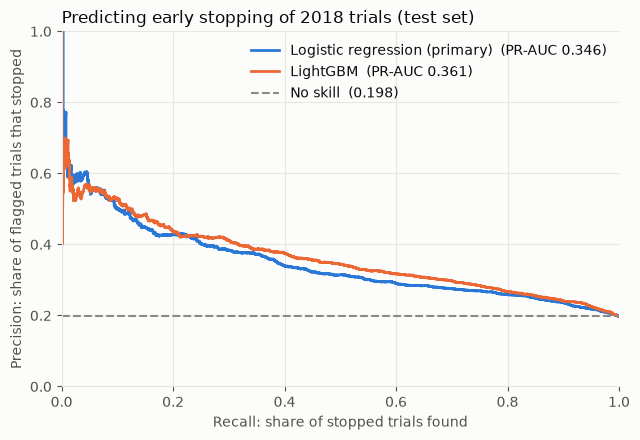

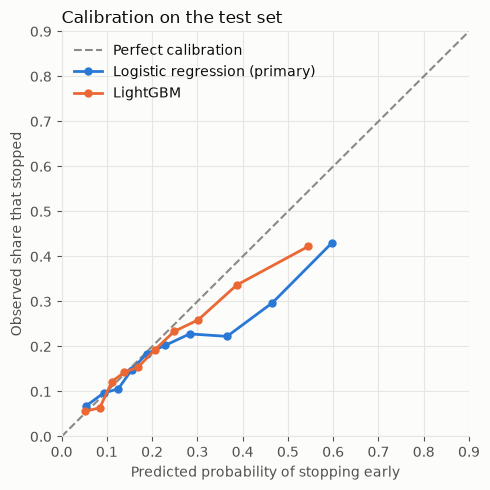

In [8]:
FIGURES = PROJECT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

STYLE = {
    "surface": "#fcfcfb", "text": "#0b0b0b", "muted": "#52514e",
    "grid": "#e7e6e2", "reference": "#8a8985",
    "logreg": "#2a78d6", "lgbm": "#eb6834",
}

def style_axes(ax):
    ax.set_facecolor(STYLE["surface"])
    ax.grid(color=STYLE["grid"], linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(STYLE["grid"])
    ax.tick_params(colors=STYLE["muted"])
    ax.xaxis.label.set_color(STYLE["muted"])
    ax.yaxis.label.set_color(STYLE["muted"])


# --- Precision-recall curve ---
fig, ax = plt.subplots(figsize=(6.5, 4.5), facecolor=STYLE["surface"])
for name, key, colour in [("Logistic regression (primary)", "logistic regression (primary)", STYLE["logreg"]),
                          ("LightGBM", "LightGBM", STYLE["lgbm"])]:
    precision, recall, _ = precision_recall_curve(y_test, test_prob[key])
    ap = average_precision_score(y_test, test_prob[key])
    ax.plot(recall, precision, color=colour, linewidth=2, label=f"{name}  (PR-AUC {ap:.3f})")
ax.axhline(y.mean(), color=STYLE["reference"], linestyle="--", linewidth=1.5,
           label=f"No skill  ({y.mean():.3f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Recall: share of stopped trials found")
ax.set_ylabel("Precision: share of flagged trials that stopped")
ax.set_title("Predicting early stopping of 2018 trials (test set)", color=STYLE["text"], loc="left")
style_axes(ax)
ax.legend(frameon=False, labelcolor=STYLE["text"])
fig.tight_layout()
fig.savefig(FIGURES / "05_pr_curve.png", dpi=150, facecolor=STYLE["surface"])
plt.show()

# --- Calibration plot ---
fig, ax = plt.subplots(figsize=(5, 5), facecolor=STYLE["surface"])
ax.plot([0, 1], [0, 1], color=STYLE["reference"], linestyle="--", linewidth=1.5, label="Perfect calibration")
for name, key, colour in [("Logistic regression (primary)", "logistic regression (primary)", STYLE["logreg"]),
                          ("LightGBM", "LightGBM", STYLE["lgbm"])]:
    obs, pred = calibration_curve(y_test, test_prob[key], n_bins=10, strategy="quantile")
    ax.plot(pred, obs, color=colour, linewidth=2, marker="o", markersize=5, label=name)
limit = max(0.8, float(np.nanmax(list(test_prob["LightGBM"]) + list(p_lr))))
limit = min(1.0, round(limit + 0.05, 1))
ax.set_xlim(0, limit); ax.set_ylim(0, limit)
ax.set_xlabel("Predicted probability of stopping early")
ax.set_ylabel("Observed share that stopped")
ax.set_title("Calibration on the test set", color=STYLE["text"], loc="left")
style_axes(ax)
ax.legend(frameon=False, labelcolor=STYLE["text"])
fig.tight_layout()
fig.savefig(FIGURES / "05_calibration.png", dpi=150, facecolor=STYLE["surface"])
plt.show()

## 9. What the final model learned

The coefficients of the primary model (trained on train + validation). They're associations, not causes. Positive = towards *stopped early*.

In [9]:
coefficients = pd.Series(
    logreg.named_steps["model"].coef_[0],
    index=logreg.named_steps["prep"].get_feature_names_out(),
).sort_values()

print("Towards COMPLETED (most negative):")
display(coefficients.head(10).round(3))
print("Towards STOPPED EARLY (most positive):")
display(coefficients.tail(10).round(3))

Towards COMPLETED (most negative):


status_2018_RECRUITING                     -0.942
is_behavioral                              -0.840
lead_sponsor_class_U.S. Fed                -0.577
primary_purpose_Health Services Research   -0.564
has_dmc_unknown                            -0.379
intervention_model_Factorial Assignment    -0.280
overdue_2018                               -0.275
lead_sponsor_class_NIH                     -0.269
n_sites                                    -0.219
phase_Early Phase 1                        -0.218
dtype: float64

Towards STOPPED EARLY (most positive):


primary_purpose_Diagnostic                  0.175
is_drug                                     0.187
intervention_model_Sequential Assignment    0.214
phase_Phase 1/Phase 2                       0.219
is_device                                   0.230
months_registration_to_start                0.304
primary_purpose_Screening                   0.309
lead_sponsor_class_Industry                 0.350
has_us_site                                 0.392
status_2018_NOT_YET_RECRUITING              0.500
dtype: float64

## 10. Validation vs test

If the test scores are close to the validation scores from notebook 04, the models generalise to a new year of trials, and the tuning in notebook 04 didn't overfit validation.

In [10]:
comparison = pd.DataFrame({
    "validation (2017, notebook 04)": {
        "logistic regression PR-AUC": settings["valid_scores"]["logistic_regression"]["pr_auc"],
        "LightGBM PR-AUC": settings["valid_scores"]["lightgbm"]["pr_auc"],
    },
    "test (2018, this notebook)": {
        "logistic regression PR-AUC": test_results.loc["logistic regression (primary)", "pr_auc"],
        "LightGBM PR-AUC": test_results.loc["LightGBM", "pr_auc"],
    },
}).round(3)
display(comparison)

,"validation (2017, notebook 04)","test (2018, this notebook)"
logistic regression PR-AUC,0.383,0.346
LightGBM PR-AUC,0.391,0.361


## 11. Findings (test set, run once)

| Model (test: 10,970 trials registered in 2018, 19.8% stopped) | PR-AUC (95% CI) | ROC-AUC (95% CI) | Brier |
|---|---|---|---|
| no model | 0.198 | 0.500 | 0.159 |
| logistic regression (pre-declared primary) | 0.346 (0.329–0.367) | 0.676 (0.664–0.688) | 0.156 |
| LightGBM | 0.361 (0.343–0.381) | 0.698 (0.686–0.710) | 0.148 |

- **Registration data predicts early stopping about 1.8× better than chance** on a year of trials the models never saw.
- **In practice:** the 10% of trials ranked riskiest stopped **42.9%** of the time (2.2× the 19.8% average). The top 5% stopped 48.5% of the time (2.45×).
- **LightGBM beats the primary model on test:** +0.015 PR-AUC, bootstrap 95% CI **+0.005 to +0.025**, which excludes 0. That's small but reliable. It's reported as observed, not by switching the primary model after seeing the test.
- **Test is lower than validation** (logistic regression 0.383 → 0.346; LightGBM 0.391 → 0.361), so the models generalise to a new year, but less well than validation suggested.
- **Already-recruiting trials:** 0.271 / 0.290 vs a base rate of 0.158. The signal holds beyond "not yet recruiting → withdrawn".
- **Calibration drifts:** for the riskiest trials the logistic regression predicts 37–60% while only 22–43% stopped. LightGBM is closer (see the figure). **The ranking is reliable; the probabilities would need re-calibration on recent trials.**
- **Likely cause:** "not yet recruiting in Dec 2018" means *just registered* for a 2018 trial but *years late* for an older trial. The model learned the second meaning and over-applies it to 2018 trials. A fix for v2 is to add the trial's age at the snapshot, or to build the cohort at a fixed trial age.
- **The final coefficients** match earlier notebooks: towards stopped are not yet recruiting, a US site, an industry sponsor, screening and diagnostic purposes, and a long gap between registration and start; towards completed are already recruiting, behavioural interventions, U.S. Fed/NIH sponsors, health-services research, and more sites.